# Lesson126 · RelBench beta: from database to evaluated predictions

Student notebook: four live functions.

This TierB complete F1 API tour is separate from TierC beta source fixtures. No historical model-score reproduction is claimed. All teaching code and available-data archives are inline; no repository import is needed.

In [ ]:
# @colab-bootstrap: proposed Colab installer, live Colab NOT_CHECKED.
import sys,subprocess,platform
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',
        'relbench==1.1.0','numpy==1.26.4','pandas==2.2.3','pyarrow==18.1.0','scikit-learn==1.5.2'])
import relbench
assert relbench.__version__=='1.1.0', 'Use the pinned RelBench1.1.0 API'
print({'python':platform.python_version(),'relbench':relbench.__version__})


In [ ]:
"""Visible L126 data/task/evaluation contracts. No model-score reproduction claim."""
import hashlib
import io
import json
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd


from types import SimpleNamespace


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 125 to this lesson</p>
<p>The individual data transformations now need a shared evaluation interface. Keep the database, prediction task and evaluator separate.</p>
<details><summary>Quick prerequisite reminder</summary><p>An evaluator compares aligned predictions and labels. Matching array lengths is insufficient: entity IDs and cutoffs must refer to the same questions in the same order.</p></details>
</aside>
<!-- sequence-review:end -->

> **The win.** Load a relational database and a prediction task, explain what each object contains, and deliver predictions that the evaluator can score without losing entity or time identity. You will also reconstruct the beta engagement rule and implement its average-precision metric.

[Student notebook](https://avistian.github.io/relational/labs/0126-relbench-beta.ipynb) · [Executed reference](https://avistian.github.io/relational/labs/html/0126-relbench-beta.html) · [Reference card](https://avistian.github.io/relational/reference/relbench-beta.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l126-reproduction.md)



## 1 · Why a benchmark needs more than a database

[Lesson 122](https://avistian.github.io/relational/lessons/0122-reg-construction.html) turned primary and foreign keys into graph structure. [Lesson 123](https://avistian.github.io/relational/lessons/0123-temporal-heterogeneous-graphs.html) restricted each query's neighborhood to its cutoff. [Lesson 124](https://avistian.github.io/relational/lessons/0124-entity-task-tables.html) attached future outcomes to entity–time pairs. [Lesson 125](https://avistian.github.io/relational/lessons/0125-pytorch-frame-deep-dive.html) encoded typed columns. Those mechanisms now need a common interface: which rows are inputs, which rows are questions, and who is allowed to see the answers?

A **benchmark** fixes a collection of prediction problems and their evaluation rules. A database alone cannot do that. Two researchers could use the same tables while predicting different outcomes, selecting different users, or measuring different metrics. Their scores would answer different questions.

> **In plain terms.** The database is the world we observe. The task tells us which questions to ask about that world. The evaluator tells us how answers are judged.

This directly serves the course mission: evidence that relational learning helps is credible only when the relational model and its baselines face the same task. Today's narrow skill is making that task contract inspectable. This is an API and evaluation lesson; it introduces no new neural architecture. [Lesson 127](https://avistian.github.io/relational/lessons/0127-relbench-v1.html) studies the later RelBench v1 benchmark and its baseline.




## 2 · Freeze the version before interpreting the API

Our primary source is **Fey et al., December 2023, arXiv:2312.04615v1**, especially [§4 and Figure 5](https://arxiv.org/html/2312.04615v1#S4). The curriculum calls this the “RelBench beta paper.” The same arXiv lineage later became the RDL position paper studied in L117. The separate [Robinson et al. benchmark paper](https://arxiv.org/abs/2407.20060) belongs to L127.

The beta describes two databases: Amazon books and Stack Exchange, with two tasks each. A **release snapshot** is a specific code revision, as opposed to whatever a repository's default branch contains today. Our historical code snapshot is `0433616ee94003fb15a4ac4d633e499d0f129077`, dated November 27, 2023. It identifies itself as version 0.1.1. This is the last reachable pre-publication commit in the inspected history, not an author-attested experiment commit. [Pinned source manifest](https://avistian.github.io/relational/labs/_sources_l126.json).

| Operation | Beta source in this lesson | Executable F1 course tour |
|---|---|---|
| Package version | Historical 0.1.1 snapshot | `relbench==1.1.0` |
| Load database | `get_dataset(name="rel-stackex")` | `F1Dataset(cache_dir=...)` |
| Read database | `dataset.db` | `dataset.get_db()` |
| Load task | `dataset.get_task("rel-stackex-engage")` | `DriverPositionTask(dataset, cache_dir=...)` |
| Read splits | `task.train_table`, `val_table`, `test_table` | `task.get_table("train"/"val"/"test")` |
| Evaluate | `task.evaluate(pred)` | `task.evaluate(pred, metrics=[mae])` |

The executable tour uses constructors to point at checksum-verified embedded archives. The registry alternative in **1.1.0** is `get_dataset("rel-f1", download=True)` followed by `get_task("rel-f1", "driver-position", download=True)`. That alternative needs working remote archives. Neither spelling is advertised here as a version-independent API.

> **Scope check.** This paper version contains no numerical predictive-results table. Reproduction means recovering and verifying its data/task/evaluation contract. It would be misleading to invent a beta score target, borrow L125's ROC-AUC target, or call a modern F1 score a beta result.



## 3 · Open the objects; do not stop at their names

A **Table** pairs a dataframe with metadata: its primary key, foreign-key destinations and optional time column. A **Database** contains a mapping from table names to these Table objects. A **Dataset** adds processing/loading behavior and validation/test cutoffs. A **Task** adds the entity being predicted, its target, prediction horizon, task tables and metric functions. [Beta Table](https://avistian.github.io/relational/labs/sources/l126/beta/relbench/data/table.py) · [Dataset](https://avistian.github.io/relational/labs/sources/l126/beta/relbench/data/dataset.py) · [Task](https://avistian.github.io/relational/labs/sources/l126/beta/relbench/data/task.py).

**Worked example.** A users table contains IDs 10, 20 and 30. An events table refers to user 20, a missing user ID, and user 99. All three foreign-key cells are syntactically possible, but only one resolves to a row. A **null** key means no recorded reference. A **dangling** key is non-null but has no matching target. Neither should silently become a valid edge.

**TODO 1 — `schema_audit`.** Count every row and column, validate primary-key uniqueness, and count resolved, null and dangling references separately. **CHECK:** the example must report one of each; duplicate primary keys must fail. The same function then examines every table in the real F1 database.

A primary key identifies a row within its table. The number of rows is not a safe upper bound on an arbitrary raw key. The released graph conversion may reindex keys; keep the mapping explicit. The schema audit operates on declared key values, not guessed positional indices.



### TODO · `schema_audit`

Return table counts plus resolved/null/dangling FK counts. Validate primary-key uniqueness.

In [ ]:
def schema_audit(tables):
    raise NotImplementedError("TODO: schema_audit")

### CHECK

Predict the result; then run. Diagnose failures before editing the check.

In [ ]:
def check_schema(fn):
    def tab(df,pk=None,fk=None):return SimpleNamespace(df=df,pkey_col=pk,fkey_col_to_pkey_table=fk or {},time_col=None)
    tabs={'users':tab(pd.DataFrame({'id':[10,20,30]}),'id'), 'events':tab(pd.DataFrame({'id':[1,2,3],'user':[20,None,99]}),'id',{'user':'users'})}
    r=fn(tabs)
    assert r['total_rows']==6 and r['tables']['users']['rows']==3
    edge=r['relations'][0]
    assert edge['resolved']==1 and edge['null']==1 and edge['dangling']==1, 'Null and dangling keys have different meanings'
    tabs['users'].df=pd.DataFrame({'id':[10,10]})
    try:fn(tabs)
    except ValueError:pass
    else:raise AssertionError('Duplicate primary keys accepted')
check_schema(schema_audit)
print("PASS: schema_audit")

## 4 · A database cap and a query cutoff solve different problems

The beta Dataset constructor retains a full database for task generation and exposes a copy capped at the test timestamp. This prevents ordinary model code from reading dated rows beyond the final test cutoff. It does **not** make every earlier training query safe. [Beta Dataset implementation](https://avistian.github.io/relational/labs/sources/l126/beta/relbench/data/dataset.py) · [paper §4.2](https://arxiv.org/html/2312.04615v1#S4.SS2).

**Worked example.** The database contains events at days 5, 10, 15, 25 and 30. The test cap is day 30. All five survive that cap. A training query at day 10 may use only days 5 and 10. Days 15 and 25 still leak if they enter that query's features or graph neighborhood.

<figure class="stream-figure" tabindex="0">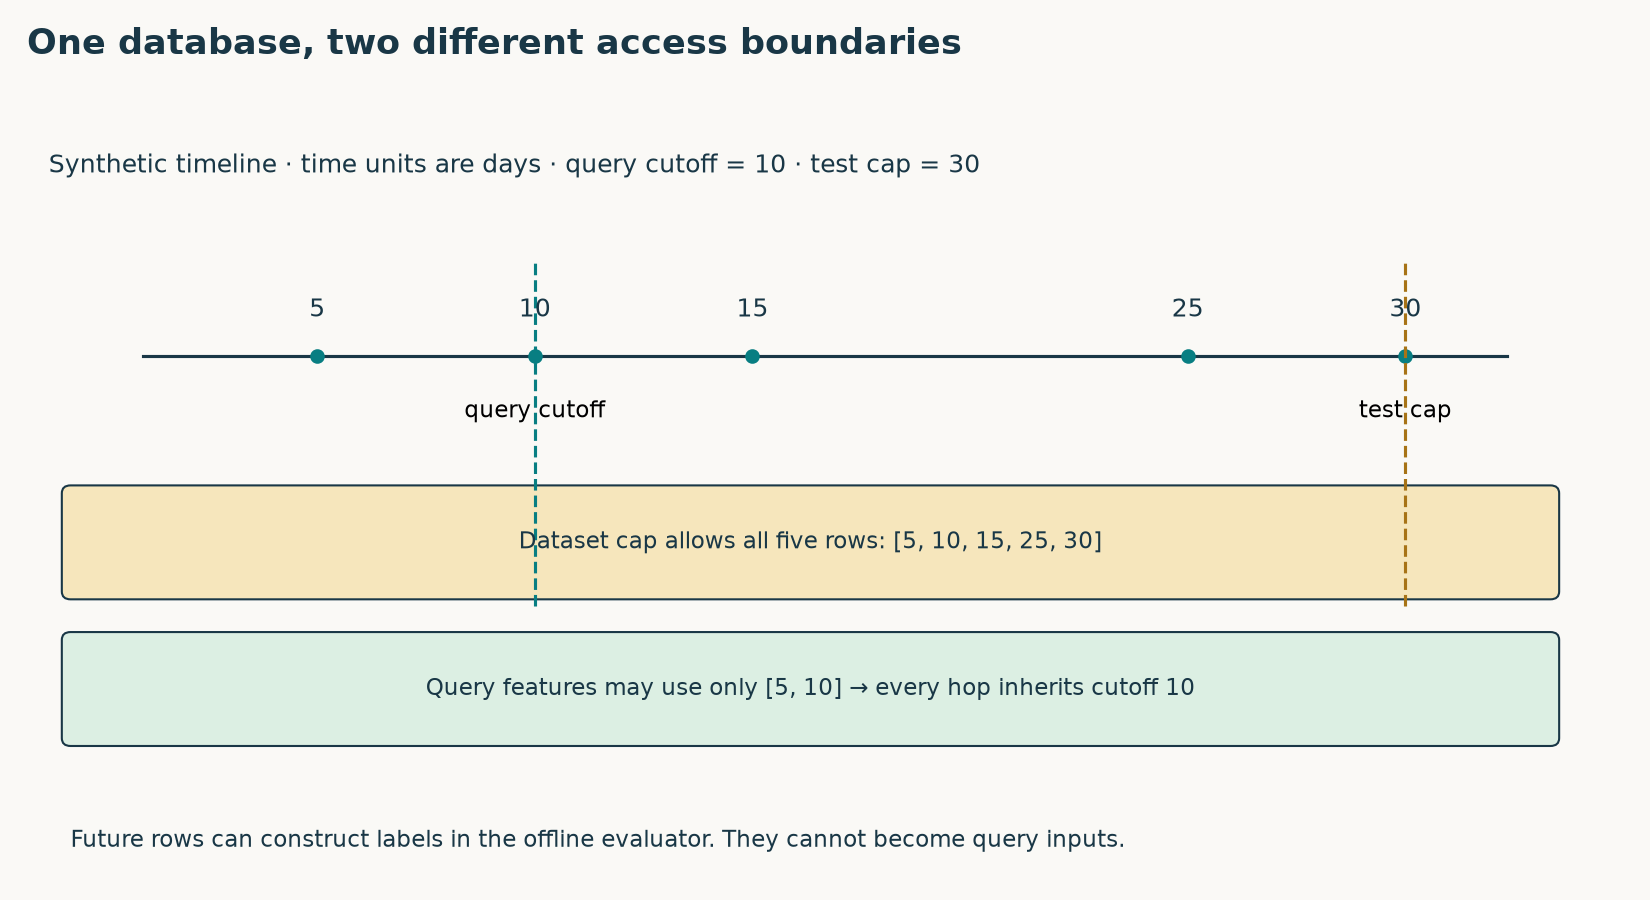<figcaption>Synthetic timeline: the dataset cap at day 30 admits five events, but the query at day 10 may use only days 5 and 10. Labels have a separate future window.</figcaption></figure>

The **prediction horizon** is the future interval whose outcome becomes the label. For a cutoff `t` and duration `Δ`, the beta helper uses the right-closed interval `(t, t+Δ]`: exclude the cutoff itself; include the endpoint. Inputs use history through `t`. The offline label builder needs future events, while the model must not receive them.

**Predict:** an event lands exactly at `t`. Does it establish prior activity? Does it make the future contribution label positive? Answer before checking the code. In the pinned release it establishes activity but does not enter the future label.

Training timestamps walk backward from `validation − Δ` in steps of `Δ`, until the database's earliest timestamp. This lets every training label window finish no later than validation. Do not replace this with an arbitrary random split.

> **Scope check.** Timestamp filtering is not proof of historical availability. The beta interface does not supply ingestion histories or versions of mutable fields. Undated tables also need an explicit availability assumption. These limitations remain visible even if every cutoff comparison passes.



## 5 · Reconstruct the beta engagement task

The selected task is **`rel-stackex-engage`**. It asks whether an eligible user contributes a post, comment or vote in the next two years. The paper calls the metric average precision. [Paper §4.4.1](https://arxiv.org/html/2312.04615v1#S4.SS4.SSS1) · [original task implementation](https://avistian.github.io/relational/labs/sources/l126/beta/relbench/tasks/stackex.py).

**Existence.** The released implementation keeps users whose creation date is no later than the cutoff.

**Eligibility.** It keeps users with at least one contribution at or before the cutoff. Whether they contribute in the future must not affect whether they enter the task.

**Outcome.** For each eligible user, the label is 1 if any qualifying future contribution exists, otherwise 0. Three source tables are normalized to `(user, time)` events. Event IDs need not be unique across tables: this task asks about existence, not a cross-table event count.

**Duration.** The code specifies `pd.Timedelta(days=365 * 2)`, exactly **730 days**. From January 1, 2019, its upper endpoint is December 31, 2020. Two calendar years would end January 1, 2021. A leap year exposes the difference. The beta task's docstring says “3 years”; the executable constant and paper say two. We record that inconsistency rather than trusting the docstring.

| User at cutoff | Past activity | Future activity in `(t,t+730d]` | Result |
|---|---|---|---|
| Existing user A | At `t` | At `t+1d` | Eligible, label 1 |
| Existing user B | Before `t` | Exactly at endpoint | Eligible, label 1 |
| Existing user C | None | At `t+2d` | Ineligible |
| Existing user D | Before `t` | One second after endpoint | Eligible, label 0 |

**TODO 2 — `engagement_table`.** Implement eligibility and labels separately. **CHECK:** deleting all future events must preserve the eligible entity–time keys, while changing the labels. Permuting input rows must preserve the task. The standalone checker additionally compares the function with the unmodified beta class and an independent SQL query.

Our normalized helper excludes null users and the raw community sentinel −1 from all activity sources. The historical source filters that sentinel in posts/comments, but only nulls in votes. The source-parity fixtures use real-user vote IDs; the full recovery operator compares all rows and rejects a mismatch instead of hiding this defensive difference. Reindexed artifacts may represent such references differently, which is another reason to verify archive identity.



In [ ]:
def fixture():
    t=pd.Timestamp('2019-01-01');end=t+pd.Timedelta(days=730)
    users=pd.DataFrame({'Id':[1,2,3,4,-1,5],'CreationDate':[t-pd.Timedelta(days=10)]*5+[t+pd.Timedelta(days=1)]})
    events=pd.DataFrame({'user':[1,1,2,2,3,4,4,-1,5,5,np.nan], 'time':[t,t+pd.Timedelta(days=1),t-pd.Timedelta(days=1),end,t+pd.Timedelta(days=2),t-pd.Timedelta(days=2),end+pd.Timedelta(seconds=1),t,t-pd.Timedelta(days=1),t+pd.Timedelta(days=1),t]})
    return users,events,t

### TODO · `engagement_table`

Separate prior eligibility from future labels; preserve cutoff and right endpoint rules.

In [ ]:
def engagement_table(users, events, cutoffs, horizon_days=730):
    raise NotImplementedError("TODO: engagement_table")

### CHECK

Predict the result; then run. Diagnose failures before editing the check.

In [ ]:
def check_engagement(fn):
    users,events,t=fixture();r=fn(users,events,[t]).sort_values('OwnerUserId')
    assert r.OwnerUserId.tolist()==[1,2,4], 'Eligibility uses existing, previously active real users'
    assert r.contribution.tolist()==[1,1,0], 'Future window is (cutoff, cutoff+730 days]'
    original=r.copy();changed=events[events.time<=t]
    no_future=fn(users,changed,[t]).sort_values('OwnerUserId')
    assert no_future.OwnerUserId.tolist()==original.OwnerUserId.tolist(), 'Future must not change eligibility'
    assert no_future.contribution.tolist()==[0,0,0], 'Cutoff event belongs to history, not target'
    again=fn(users,events.sample(frac=1,random_state=4),[t])
    pd.testing.assert_frame_equal(r.reset_index(drop=True),again.sort_values('OwnerUserId').reset_index(drop=True))
check_engagement(engagement_table)
print("PASS: engagement_table")

## 6 · Hidden targets are only one half of evaluation integrity

A public test table contains the query identity but hides its target. The beta task retains a separate full test table for evaluation; accessing `task.test_table` initializes that reference in the historical API. The modern tour uses `get_table("test")`. This is an API convention for separating model inputs from scoring, not a security boundary against an author who possesses the files.

A **query key** combines the target entity and prediction time. Driver A on one date and driver A on another date are different questions. Sampling or batching may rearrange them. An evaluator receiving an ordinary array cannot infer that rearrangement.

<figure class="stream-figure" tabindex="0">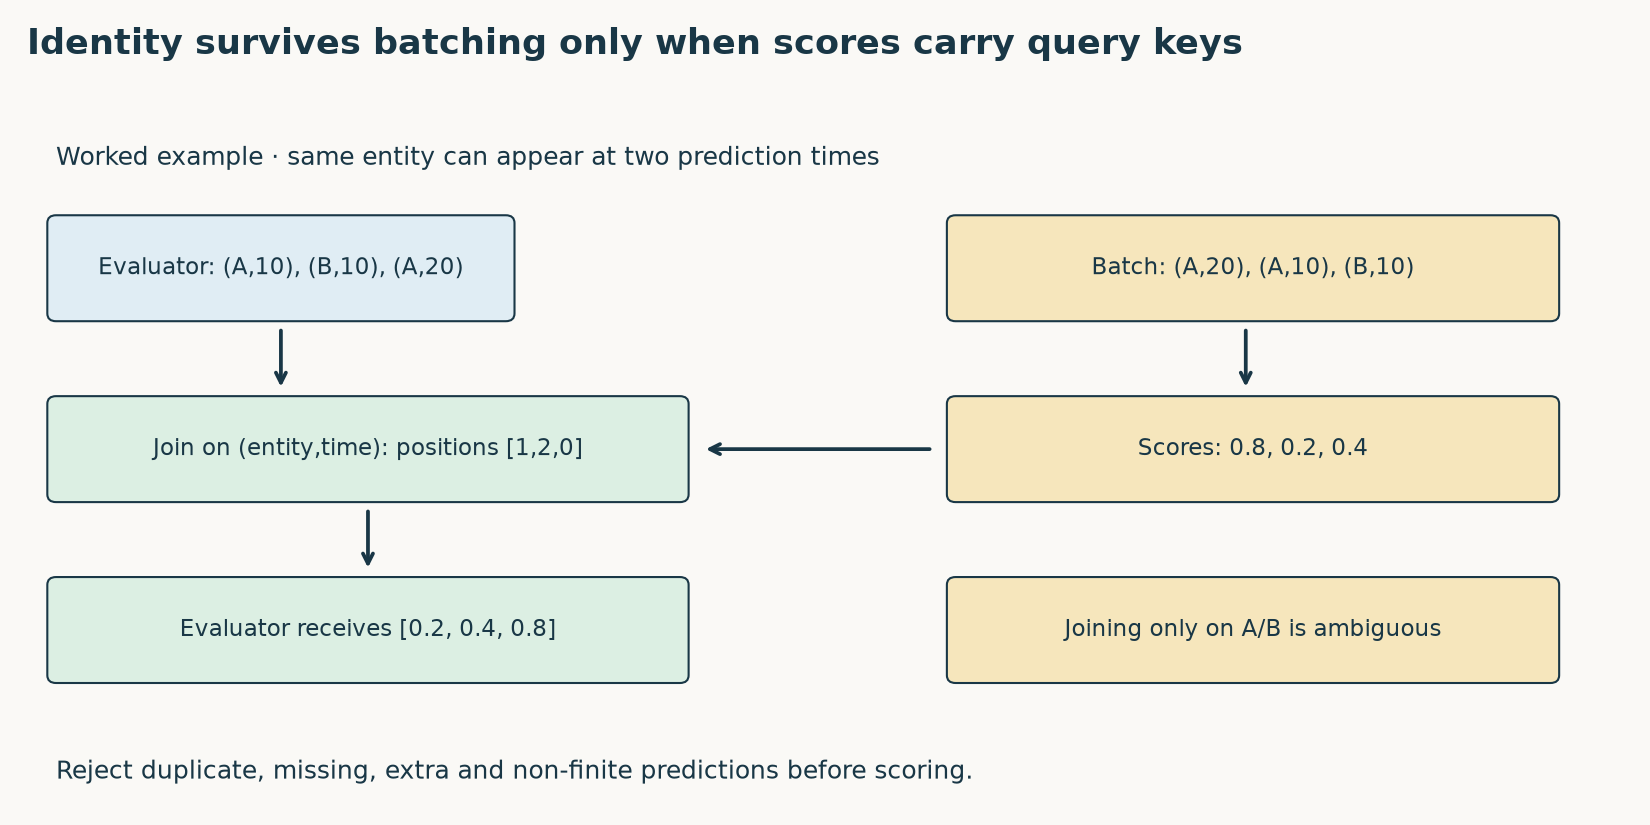<figcaption>Worked keyed-score example: positions 1,2,0 restore evaluator order; entity A alone cannot distinguish two query times.</figcaption></figure>

**Worked example.** The evaluator expects `(A,10), (B,10), (A,20)`. A batch returns `(A,20):0.8, (A,10):0.2, (B,10):0.4`. The correct score array is `[0.2,0.4,0.8]`. Returning the batch's `[0.8,0.2,0.4]` has the right length and the wrong meaning.

**TODO 3 — `align_predictions`.** Require an exact one-to-one match between query keys and prediction keys; gather scores in query order. **CHECK:** reject duplicates, missing keys, extra keys and non-finite scores. Joining only on entity must not accidentally merge different times. This contract concerns unique task queries; repeated sampled neighbor IDs inside a GNN batch are a different object.

The F1 tour freezes a predictor using only the median training label, attaches its predictions to keys, shuffles the keyed output and aligns it again. A constant predictor alone cannot expose an ordering error, so the separate nonconstant CHECK fixture is essential.



### TODO · `align_predictions`

Require exact entity/time keys and return evaluator order. Reject ambiguous/missing outputs.

In [ ]:
def align_predictions(queries, predictions, keys, score_col='score'):
    raise NotImplementedError("TODO: align_predictions")

### CHECK

Predict the result; then run. Diagnose failures before editing the check.

In [ ]:
def check_alignment(fn):
    q=pd.DataFrame({'id':[1,2,1],'time':[10,10,20]});p=pd.DataFrame({'id':[1,1,2],'time':[20,10,10],'score':[.8,.2,.4]})
    np.testing.assert_array_equal(fn(q,p,['id','time']),[.2,.4,.8])
    for bad in [p.iloc[:2],pd.concat([p,p.iloc[:1]],ignore_index=True),p.assign(score=[np.nan,.2,.4]),pd.concat([p,p.assign(id=99).iloc[:1]],ignore_index=True)]:
        try:fn(q,bad,['id','time'])
        except ValueError:pass
        else:raise AssertionError('Missing/extra/duplicate/nonfinite predictions accepted')
check_alignment(align_predictions)
print("PASS: align_predictions")

## 7 · Average precision is a threshold calculation

A binary label is 0 or 1. A **score** ranks examples from more likely positive to less likely positive; AP does not require calibrated probabilities. At a threshold, **precision** is the number of positives retrieved divided by all retrieved rows. **Recall** is positives retrieved divided by all positives in the evaluation set.

> **In plain terms.** Lower the threshold. Each time you recover more positives, record how precise the retrieved set is. Weight that precision by how much recall you gained.

For distinct descending score thresholds indexed by `k`,

`AP = Σ_k (recall_k − recall_(k−1)) × precision_k`, with initial recall 0.

This is non-interpolated average precision. It is not ROC-AUC and not the trapezoidal area under a precision–recall curve. The pinned beta metric calls scikit-learn's `average_precision_score`; the library documents this weighting explicitly. [Beta metrics](https://avistian.github.io/relational/labs/sources/l126/beta/relbench/metrics.py) · [scikit-learn definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

**Worked example.** Labels `[1,0,1,0,1]` have three positives. Scores `[0.9,0.5,0.5,0.1,0.1]` create three thresholds. At 0.9, precision is 1 and recall increases by 1/3. At 0.5, precision is 2/3 and recall increases by another 1/3. At 0.1, precision is 3/5 and the final recall gain is 1/3. Thus AP is `1/3 + 2/9 + 1/5 = 0.755556`.

<figure class="stream-figure" tabindex="0">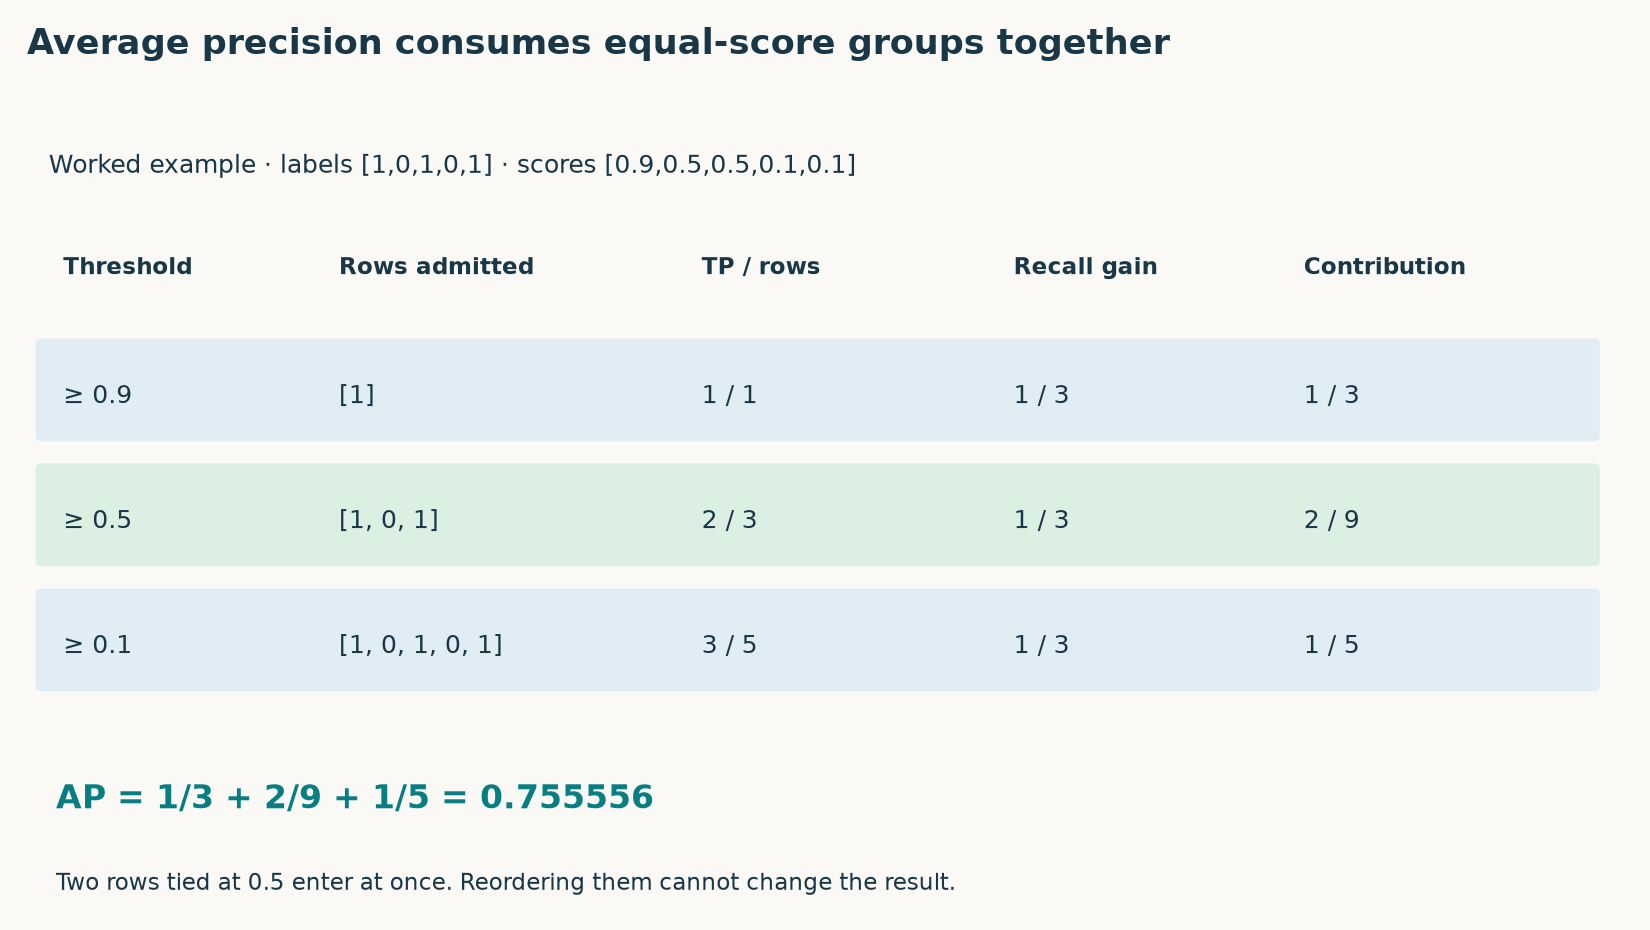<figcaption>Synthetic five-row example: three tied-score thresholds contribute 1/3, 2/9 and 1/5 to AP 0.755556.</figcaption></figure>

**Ties.** A score of 0.5 cannot admit one tied row while excluding another. Process the whole tie at once. Otherwise an arbitrary ordering of equal scores can change the reported score.

Static AP trace: labels[1,0,1,0,1], scores[0.9,0.5,0.5,0.1,0.1]. Grouped AP=0.755556. Reordering within ties leaves it unchanged. Giving every row score0.5 yields prevalence3/5=0.6.

**Save enough score precision to preserve the ranking.** Consider just two examples:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Label</th><th>Original score</th><th>Rounded to 3 decimals</th></tr></thead><tbody><tr><td>1</td><td>0.5004</td><td>0.500</td></tr><tr><td>0</td><td>0.5003</td><td>0.500</td></tr></tbody></table>

The original ranking retrieves the positive first, so AP is 1. After rounding, one threshold retrieves both examples: recall jumps from 0 to 1 at precision 1/2, so AP is 0.5. The model and labels did not change; the exported scores did. Keep the original numerical predictions for scoring and round only their presentation.

**Try the change.** Replace every original score `s` with `3s+7`, without rounding. Does AP change? Why is this different from merging scores into a tie?

<details><summary>Check the ranking</summary><p>AP stays 1: the transformation strictly preserves score order and ties. The scores need not lie between 0 and 1 for AP. Rounding is different because it can erase an ordering distinction. These calculations assume the transformed values remain finite and distinct in the stored numerical format.</p></details>

**TODO 4 — `average_precision`.** Sort descending, locate the ends of equal-score groups, compute cumulative positives and weight precision by recall increments. **CHECK:** equal scores for every row give AP equal to positive prevalence. Our explicit convention returns 0 when no positives exist, matching the reference's result; that degenerate split still deserves a warning in an experiment report. Reject nonbinary labels and non-finite scores.



### TODO · `average_precision`

Compute recall increments only at the ends of equal-score groups.

In [ ]:
def average_precision(y, scores):
    raise NotImplementedError("TODO: average_precision")

### CHECK

Predict the result; then run. Diagnose failures before editing the check.

In [ ]:
def check_ap(fn):
    # Descending thresholds .9,.5,.1; recall increments 1/3 each.
    y=np.array([1,0,1,0,1]);s=np.array([.9,.5,.5,.1,.1])
    np.testing.assert_allclose(fn(y,s),(1+2/3+3/5)/3,atol=1e-14)
    np.testing.assert_allclose(fn([1,0,0,1],[.5]*4),.5)
    assert fn([0,0],[.2,.9])==0 and fn([1,1],[.2,.9])==1
    for yy,ss in [([],[]),([0,2],[.1,.2]),([0,1],[.1]),([0,1],[np.inf,.2])]:
        try:fn(yy,ss)
        except ValueError:pass
        else:raise AssertionError('Invalid evaluator inputs accepted')
check_ap(average_precision)
print("PASS: average_precision")

### PROVIDED · `beta_events`

Normalize activity sources without assuming their event IDs share one namespace.

In [ ]:
def beta_events(tables):
    """Normalize three activity sources; IDs across tables need not be unique."""
    parts = []
    for name, col in [('posts', 'OwnerUserId'), ('comments', 'UserId'), ('votes', 'UserId')]:
        part = tables[name].df[[col, 'CreationDate']].rename(columns={col: 'user', 'CreationDate': 'time'})
        parts.append(part)
    return pd.concat(parts, ignore_index=True)

### PROVIDED · `beta_cutoffs`

Read the released backward fixed-duration split grid.

In [ ]:
def beta_cutoffs(min_time, validation='2019-01-01', test='2021-01-01', horizon_days=730):
    """Release training grid: walk backward in fixed duration, never calendar years."""
    delta = pd.Timedelta(days=horizon_days)
    return {'train': list(pd.date_range(pd.Timestamp(validation)-delta, pd.Timestamp(min_time), freq=-delta)),
            'val': [pd.Timestamp(validation)], 'test': [pd.Timestamp(test)]}

### PROVIDED · `unpack_verified`

Verify bytes before loading the embedded archives.

In [ ]:
def unpack_verified(raw, digest, destination):
    """Check archive bytes before reading; refuse paths outside destination."""
    if hashlib.sha256(raw).hexdigest() != digest:
        raise ValueError('Archive checksum mismatch')
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(raw)) as archive:
        for name in archive.namelist():
            path = (destination / name).resolve()
            if not path.is_relative_to(destination):
                raise ValueError('Archive path escapes destination')
        archive.extractall(destination)

### PROVIDED · `f1_tour`

Follow your schema and alignment functions through actual RelBench objects. The fixed training median is the complete predictor.

In [ ]:
def f1_tour(db_raw, task_raw, root):
    """Complete pinned RelBench 1.1.0 F1 API tour, separate from beta evidence.

    The sole predictor is the training-label median. It demonstrates the API;
    there is no GNN training, model comparison or published-score target.
    """
    import relbench
    from relbench.datasets.f1 import F1Dataset
    from relbench.tasks.f1 import DriverPositionTask
    from relbench.metrics import mae
    if relbench.__version__ != '1.1.0':
        raise RuntimeError('This tour pins relbench==1.1.0')
    root = Path(root)
    unpack_verified(db_raw, 'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482', root)
    unpack_verified(task_raw, '775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e', root/'tasks')
    dataset = F1Dataset(cache_dir=str(root))
    task = DriverPositionTask(dataset, cache_dir=str(root/'tasks/driver-position'))
    db = dataset.get_db()
    schema = schema_audit(db.table_dict)
    train = task.get_table('train')
    validation = task.get_table('val')
    test_queries = task.get_table('test')
    assert task.target_col not in test_queries.df, 'Public test table must mask labels'
    center = float(np.median(train.df[task.target_col]))
    query = test_queries.df
    keyed = query.copy()
    keyed['score'] = center
    shuffled = keyed.sample(frac=1, random_state=126)
    predictions = align_predictions(query, shuffled, [task.entity_col, task.time_col])
    metrics = task.evaluate(predictions, metrics=[mae])
    val_metrics = task.evaluate(np.full(len(validation.df), center), validation, metrics=[mae])
    # Labels are opened only by the offline author audit after predictions freeze.
    full_test = task.get_table('test', mask_input_cols=False)
    independent_mae = float(np.mean(np.abs(full_test.df[task.target_col].to_numpy()-predictions)))
    np.testing.assert_allclose(metrics['mae'], independent_mae, rtol=0, atol=1e-12)
    result = {'status': 'PASS', 'scope': 'COURSE_ONLY: complete v1 F1 API tour',
              'schema': schema, 'splits': {'train': len(train.df), 'val': len(validation.df), 'test': len(query)},
              'training_median': center, 'validation_mae': val_metrics['mae'], 'test_mae': metrics['mae'],
              'test_labels_masked': True, 'prediction_alignment': 'EXACT',
              'historical_beta_full_contract': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}
    predictions_frame = query.copy()
    predictions_frame['score'] = predictions
    predictions_frame['target_for_offline_audit_only'] = full_test.df[task.target_col].to_numpy()
    return result, predictions_frame

### RUN · your beta contracts composed on a fixture

Synthetic only. These hand-declared scores are not trained predictions. Change a boundary event and explain what moves.

In [ ]:
users,events,t=fixture()
queries=engagement_table(users,events,[t])
keyed=queries[['OwnerUserId','timestamp']].copy()
keyed['score']=[.9,.5,.1]
scores=align_predictions(queries,keyed.iloc[::-1],['OwnerUserId','timestamp'])
assert average_precision(queries.contribution,scores)==1.0
print(queries.to_string(index=False))
print('Synthetic fixture AP:',average_precision(queries.contribution,scores))
print('Fixed-duration train cutoffs:', beta_cutoffs('2014-01-01')['train'])

## 8 · Execute the complete available-data package tour

The notebook embeds checksum-verified F1 database and driver-position task archives. There is no row cap or remote data dependency in its default execution. The complete course run exercises actual RelBench 1.1.0 objects, calls your schema/alignment functions and scores the fixed training-median predictor. **MAE**, mean absolute error, averages `abs(prediction − target)` in position units. It is appropriate for this regression task, whereas the beta engagement task is binary and uses AP.

**Author-reference execution · complete F1 API tour · COURSE_ONLY.**

| Table | Rows exposed after the test cap |
|---|---:|
| constructor_results | 9,408 |
| constructor_standings | 10,170 |
| circuits | 77 |
| qualifying | 4,082 |
| drivers | 857 |
| results | 20,323 |
| races | 820 |
| standings | 28,115 |
| constructors | 211 |

**74,063 rows**, nine tables, 13 declared foreign-key relations. All **7,453 train / 499 validation / 760 test** task rows are loaded. The training median is **13.333333**; validation MAE **4.135571**, test MAE **4.444671**. All test predictions were independently rescored in SQL. [Measured report](https://avistian.github.io/relational/labs/evidence/l126/summary.json) · [Independent audit](https://avistian.github.io/relational/labs/_audit_l126_results.json).


The predictor has no hyperparameter search, stochastic training, checkpoint selection or seed ensemble. Its fixed shuffle seed changes only presentation order. Repeating an identical deterministic evaluation over “seeds” would not create meaningful uncertainty. The measured scores show that the API path works; they do not establish model superiority or reproduce an RDL result.

**Compatibility note.** We request only `metrics=[mae]`. RelBench 1.1.0's additional RMSE helper calls a scikit-learn argument removed from the installed version. The first unrestricted evaluator call failed for that reason. Selecting the declared MAE metric preserves its calculation and makes this dependency boundary explicit. The author environment is recorded separately from the proposed Colab setup.



In [ ]:
# RUN: real, complete database/task through your live schema/alignment functions.
import base64,tempfile
payload = {'f1-db.zip': '...', 'f1-task.zip': '...'}
with tempfile.TemporaryDirectory(prefix='l126-notebook-db-') as folder:
    report,predictions=f1_tour(base64.b64decode(payload['f1-db.zip']),base64.b64decode(payload['f1-task.zip']),folder)
assert report['schema']['total_rows']==74063 and report['splits']=={'train':7453,'val':499,'test':760}
Path('l126-report.json').write_text(json.dumps(report,indent=2))
predictions.to_csv('l126-predictions.csv',index=False)
print('Complete database:', report['schema']['total_rows'], 'rows')
print('Task splits:', report['splits'])
print('Train median:',report['training_median'],'Test MAE:',report['test_mae'])
print('Historical beta full reconstruction: NOT_RUN; course tour: PASS')


## 9 · What has—and has not—been reproduced

The fresh source audit runs the original beta task class, Dataset and test-mask/evaluator path. It checks 82 synthetic task/cutoff cases against both our implementation and independent SQL, and 200 AP cases against the released metric. These cases establish tested semantics, not original-data identity. The recovery operator's complete reconstruction path also passes a synthetic archive-table test and rejects a corrupted label.

All seven original/alternate database, task and raw-data endpoint probes returned 404 on September 27, 2026. A web-archive query timed out. No matching historical archive was recovered. The beta database hash starts `dfb84faa`; the later L125 database hash starts `deb00ccd`. They are not interchangeable. [Availability audit](https://avistian.github.io/relational/labs/_paper_audit_l126_results.json).

| Evidence | Status | Permitted conclusion |
|---|---|---|
| Pinned beta source + synthetic task/evaluator audit | PASS | Tested source semantics agree |
| Complete v1 F1 database/task API tour | PASS · COURSE_ONLY | All available rows and predictions audited |
| Full historical beta archive reconstruction | NOT_RUN · BLOCKED_DATA | Required bytes not recovered |
| Numerical beta paper-score reproduction | NOT_APPLICABLE | This version has no score table |
| Whole-paper/historical identity | NOT_ESTABLISHED | Cannot infer identity from passing fixtures |
| Learner mastery | PENDING_WRITTEN_DEFENSE | Author execution does not score your work |

The [recovery operator](https://avistian.github.io/relational/labs/_recover_l126.py) requires the exact database and engagement archives, reconstructs every split, compares both original-source and archived labels, and verifies public test masking. Its full historical-data path remains unexecuted. Original beta training/model code is preserved in the notebook's source appendix; it contains stale `rtb` imports and is not presented as a validated trainer. No cloud training was launched; spending is **$0**.



## 10 · Lab, written exit and return visits

Run the four TODO/CHECK pairs, then execute the full F1 tour. Submit `l126-report.json`, keyed predictions, your implementations, and this written defense:

1. Explain the difference between a database's final test cap and a training query's cutoff. Name one leak that survives the first.
2. Trace one beta engagement label, including user existence, eligibility and both interval endpoints. Explain the leap-year effect.
3. Explain why correct array length cannot establish correct evaluation. State the key you would carry through batches.
4. Derive the worked AP value without running code. Explain why a tie must enter together.
5. Separate source parity, complete modern-data execution and historical reproduction. Identify the missing artifacts precisely.

**Exit rubric.** Each item earns 0 (missing/incorrect), 1 (correct but incomplete), or 2 (correct with a concrete example). Passing requires all four live functions, a successful complete tour, at least 8/10, and no unresolved temporal, identity or reproduction-scope error. Paste your explanation to the teacher for feedback; ask follow-up questions wherever the source and implementation seem to disagree.

**Spaced retrieval.** Tomorrow, redraw the object boundaries and AP thresholds from memory. In seven days, diagnose a shuffled prediction file without opening this lesson. In thirty days, inspect another benchmark's dataset/task/evaluator interface and identify which historical claims its artifacts actually support.

Explain which historical identity claim remains unestablished after all source checks pass.



## Primary-source reading ledger

Read [the full beta paper](https://arxiv.org/html/2312.04615v1), with §4 as today's close reading. For §§1–2, state the problem and task-table idea in your own words. For §3, trace the schema → entity graph → temporal computation graph → head route already developed in L117 and L122–125. For §4, map each package promise to a checked API operation. For §§5–7, choose one proposed research direction and explain why this lesson's evidence does not establish that claim. Then inspect the pinned task, dataset and metric source linked above.

<!-- sequence-next:start -->
**Carry this forward.** Freeze the entire neural training and selection protocol for RelBench v1. [Continue to Lesson 127](https://avistian.github.io/relational/lessons/0127-relbench-v1.html).
<!-- sequence-next:end -->


## EXIT files

Submit `l126-report.json`, `l126-predictions.csv`, four implementations and the five written answers. Source and author execution do not establish learner mastery. Learner remains PENDING_WRITTEN_DEFENSE.

## NEXT STEP · historical recovery

The checkout command `python labs/_recover_l126.py --archive-dir /path/to/archives --report /tmp/l126-recovered.json` verifies both original hashes and reconstructs all split labels. Missing bytes return exit2. Full historical execution is NOT_RUN; synthetic recovery-path checks pass. See the linked protocol for exact environment and source gaps.

## Source appendix · pinned beta implementation

Read-only original code, **not executed by this notebook**. The task source is independently executed by the checkout audit. The training example has stale `rtb` imports and is not a validated runnable trainer. We retain it to make the historical architecture/training boundary inspectable; no numerical target exists in the beta paper. MIT license follows.

### LICENSE

```
The MIT License (MIT)

Copyright (c) 2023 RelBench Team

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.

```

### relbench/data/dataset.py

```python
import hashlib
import os
import shutil
import tempfile
import time
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Type, Union

import pandas as pd
import pooch

from relbench import _pooch
from relbench.data.database import Database
from relbench.data.task import Task
from relbench.utils import unzip_processor


class Dataset:
    def __init__(
        self,
        db: Database,
        val_timestamp: pd.Timestamp,
        test_timestamp: pd.Timestamp,
        task_cls_list: List[Type[Task]],
    ) -> None:
        self._full_db = db
        self.val_timestamp = val_timestamp
        self.test_timestamp = test_timestamp
        self.task_cls_dict = {task_cls.name: task_cls for task_cls in task_cls_list}

        self.db = db.upto(test_timestamp)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}()"

    @property
    def task_names(self) -> List[str]:
        return list(self.task_cls_dict.keys())

    def get_task(self, task_name: str, *args, **kwargs) -> Task:
        return self.task_cls_dict[task_name](self, *args, **kwargs)


class RelBenchDataset(Dataset):
    name: str
    val_timestamp: pd.Timestamp
    test_timestamp: pd.Timestamp
    task_cls_list: List[Type[Task]]

    db_dir: str = "db"

    def __init__(self, *, process: bool = False) -> None:
        if process:
            print("making Database object from raw files...")
            tic = time.time()
            db = self.make_db()
            toc = time.time()
            print(f"done in {toc - tic:.2f} seconds.")

            print("reindexing pkeys and fkeys...")
            tic = time.time()
            db.reindex_pkeys_and_fkeys()
            toc = time.time()
            print(f"done in {toc - tic:.2f} seconds.")

        else:
            db_path = _pooch.fetch(
                f"{self.name}/{self.db_dir}.zip",
                processor=unzip_processor,
                progressbar=True,
            )
            print(f"loading Database object from {db_path}...")
            tic = time.time()
            db = Database.load(db_path)
            toc = time.time()
            print(f"done in {toc - tic:.2f} seconds.")

        super().__init__(
            db, self.val_timestamp, self.test_timestamp, self.task_cls_list
        )

    def make_db(self) -> Database:
        raise NotImplementedError

    def pack_db(self, root: Union[str, os.PathLike]) -> Tuple[str, str]:
        with tempfile.TemporaryDirectory() as tmpdir:
            db_path = Path(tmpdir) / self.db_dir
            print(f"saving Database object to {db_path}...")
            tic = time.time()
            self._full_db.save(db_path)
            toc = time.time()
            print(f"done in {toc - tic:.2f} seconds.")

            print("making zip archive for db...")
            tic = time.time()
            zip_path = Path(root) / self.name / self.db_dir
            zip_path = shutil.make_archive(zip_path, "zip", db_path)
            toc = time.time()
            print(f"done in {toc - tic:.2f} seconds.")

        with open(zip_path, "rb") as f:
            sha256 = hashlib.sha256(f.read()).hexdigest()

        print(f"upload: {zip_path}")
        print(f"sha256: {sha256}")

        return f"{self.name}/{self.db_dir}.zip", sha256

```

### relbench/data/task.py

```python
import hashlib
import os
import shutil
import tempfile
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import TYPE_CHECKING, Callable, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
from numpy.typing import NDArray

from relbench import _pooch
from relbench.data.database import Database
from relbench.data.table import Table
from relbench.utils import unzip_processor

if TYPE_CHECKING:
    from relbench.data import BenchmarkDataset, Dataset


class Task:
    r"""A task on a dataset."""

    def __init__(
        self,
        dataset: "Dataset",
        timedelta: pd.Timedelta,
        target_col: str,
        metrics: List[Callable[[NDArray, NDArray], float]],
    ):
        self.dataset = dataset
        self.timedelta = timedelta
        self.target_col = target_col
        self.metrics = metrics

        self._full_test_table = None

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(dataset={self.dataset})"

    def make_table(
        self,
        db: Database,
        timestamps: "pd.Series[pd.Timestamp]",
    ) -> Table:
        r"""To be implemented by subclass."""

        # TODO: ensure that tasks follow the right-closed convention

        raise NotImplementedError

    @property
    @lru_cache
    def train_table(self) -> Table:
        """Returns the train table for a task."""

        return self.make_table(
            self.dataset.db,
            pd.date_range(
                self.dataset.val_timestamp - self.timedelta,
                self.dataset.db.min_timestamp,
                freq=-self.timedelta,
            ),
        )

    @property
    @lru_cache
    def val_table(self) -> Table:
        r"""Returns the val table for a task."""

        return self.make_table(
            self.dataset.db,
            pd.Series([self.dataset.val_timestamp]),
        )

    def _mask_input_cols(self, table: Table) -> Table:
        input_cols = [
            table.time_col,
            *table.fkey_col_to_pkey_table.keys(),
        ]
        return Table(
            df=table.df[input_cols],
            fkey_col_to_pkey_table=table.fkey_col_to_pkey_table,
            pkey_col=table.pkey_col,
            time_col=table.time_col,
        )

    @property
    @lru_cache
    def test_table(self) -> Table:
        r"""Returns the test table for a task."""

        table = self.make_table(
            self.dataset._full_db,
            pd.Series([self.dataset.test_timestamp]),
        )
        self._full_test_table = table

        return self._mask_input_cols(table)

    def evaluate(
        self,
        pred: NDArray[np.float64],
        target_table: Optional[Table] = None,
        metrics: Optional[List[Callable[[NDArray, NDArray], float]]] = None,
    ) -> Dict[str, float]:
        if metrics is None:
            metrics = self.metrics

        if target_table is None:
            target_table = self._full_test_table

        target = target_table.df[self.target_col].to_numpy()

        return {fn.__name__: fn(target, pred) for fn in metrics}


class RelBenchTask(Task):
    name: str
    task_type: str
    entity_col: str
    entity_table: str
    time_col: str

    timedelta: pd.Timedelta
    target_col: str
    metrics: List[Callable[[NDArray, NDArray], float]]

    task_dir: str = "tasks"
    train_table_name: str = "train"
    val_table_name: str = "val"
    test_table_name: str = "test"
    full_test_table_name: str = "full_test"

    def __init__(self, dataset: "RelBenchDataset", process: bool = False) -> None:
        self.process = process

        if not process:
            task_path = _pooch.fetch(
                f"{dataset.name}/{self.task_dir}/{self.name}.zip",
                processor=unzip_processor,
                progressbar=True,
            )
            self._dummy_db = Database.load(task_path)

        super().__init__(
            dataset=dataset,
            timedelta=self.timedelta,
            target_col=self.target_col,
            metrics=self.metrics,
        )

    @property
    def train_table(self) -> Table:
        if self.process:
            return super().train_table
        return self._dummy_db.table_dict[self.train_table_name]

    @property
    def val_table(self) -> Table:
        if self.process:
            return super().val_table
        return self._dummy_db.table_dict[self.val_table_name]

    @property
    def test_table(self) -> Table:
        if self.process:
            return super().test_table
        self._full_test_table = self._dummy_db.table_dict[self.full_test_table_name]
        return self._dummy_db.table_dict[self.test_table_name]

    def pack_tables(self, root: Union[str, os.PathLike]) -> Tuple[str, str]:
        _dummy_db = Database(
            table_dict={
                self.train_table_name: self.train_table,
                self.val_table_name: self.val_table,
                self.test_table_name: self.test_table,
                self.full_test_table_name: self._full_test_table,
            }
        )

        with tempfile.TemporaryDirectory() as tmpdir:
            task_path = Path(tmpdir) / self.name
            _dummy_db.save(task_path)

            zip_base_path = Path(root) / self.dataset.name / self.task_dir / self.name
            zip_path = shutil.make_archive(zip_base_path, "zip", task_path)

        with open(zip_path, "rb") as f:
            sha256 = hashlib.sha256(f.read()).hexdigest()

        print(f"upload: {zip_path}")
        print(f"sha256: {sha256}")

        return f"{self.dataset.name}/{self.task_dir}/{self.name}.zip", sha256

```

### relbench/tasks/stackex.py

```python
import os
from typing import Dict, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm

from relbench.data import Database, RelBenchTask, Table
from relbench.metrics import accuracy, average_precision, f1, mae, rmse, roc_auc
from relbench.utils import get_df_in_window


class EngageTask(RelBenchTask):
    r"""Predict if a user will make any votes/posts/comments in the next 3 years."""

    name = "rel-stackex-engage"
    task_type = "binary_classification"
    entity_col = "OwnerUserId"
    entity_table = "users"
    time_col = "timestamp"
    target_col = "contribution"
    timedelta = pd.Timedelta(days=365 * 2)
    metrics = [average_precision, accuracy, f1, roc_auc]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        r"""Create Task object for UserContributionTask."""
        timestamp_df = pd.DataFrame({"timestamp": timestamps})
        comments = db.table_dict["comments"].df
        votes = db.table_dict["votes"].df
        posts = db.table_dict["posts"].df
        posts = posts[
            posts.OwnerUserId != -1
        ]  ## when user id is -1, it is stats exchange community, not a real person
        posts = posts[posts.OwnerUserId.notnull()]  ## 1153 null posts

        users = db.table_dict["users"].df
        votes = votes[votes.UserId.notnull()]
        posts = posts[posts.OwnerUserId.notnull()]

        comments = comments[
            comments.UserId != -1
        ]  ## when user id is -1, it is stats exchange community, not a real person
        comments = comments[comments.UserId.notnull()]  ## 2439 null comments

        def get_values_in_window(row, posts, users):
            posts_window = get_df_in_window(posts, "CreationDate", row, self.timedelta)
            comments_window = get_df_in_window(
                comments, "CreationDate", row, self.timedelta
            )
            votes_window = get_df_in_window(votes, "CreationDate", row, self.timedelta)

            user_made_posts_in_this_period = posts_window.OwnerUserId.unique()
            user_made_comments_in_this_period = comments_window.UserId.unique()
            user_made_votes_in_this_period = votes_window.UserId.unique()

            # user_active_in_this_period = user_made_posts_in_this_period

            user_active_in_this_period = np.union1d(
                np.union1d(
                    user_made_posts_in_this_period, user_made_comments_in_this_period
                ),
                user_made_votes_in_this_period,
            )

            users_exist = users[
                users.CreationDate <= row["timestamp"]
            ]  ## only looking at existing users
            users_exist_ids = users_exist.Id.values

            user_made_votes = votes[
                votes.CreationDate <= row["timestamp"]
            ].UserId.unique()
            user_made_comments = comments[
                comments.CreationDate <= row["timestamp"]
            ].UserId.unique()
            user_made_posts = posts[
                posts.CreationDate <= row["timestamp"]
            ].OwnerUserId.unique()
            active_user_before_this_time = np.union1d(
                np.union1d(user_made_votes, user_made_comments), user_made_posts
            )
            # active_user_before_this_time = user_made_posts
            users_exist_and_active_ids = np.intersect1d(
                users_exist_ids, active_user_before_this_time
            )

            user2churn = pd.DataFrame()
            user2churn["OwnerUserId"] = users_exist_and_active_ids
            user2churn["timestamp"] = row["timestamp"]

            user2churn["contribution"] = user2churn.OwnerUserId.apply(
                lambda x: 1 if x in user_active_in_this_period else 0
            )  ## 1: contributed; 0: not contributed
            return user2churn

        tqdm.pandas()
        # Apply function to each time window
        res = timestamp_df.progress_apply(
            lambda row: get_values_in_window(row, posts, users), axis=1
        )
        df = pd.concat(res.values)

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        )


class VotesTask(RelBenchTask):
    r"""Predict the number of upvotes that a question that is posted within the last 2 years will receive in the next 6 months. ?"""
    name = "rel-stackex-votes"
    task_type = "regression"
    entity_col = "PostId"
    entity_table = "posts"
    time_col = "timestamp"
    target_col = "popularity"
    timedelta = pd.Timedelta(days=180)
    metrics = [mae, rmse]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        r"""Create Task object for post_votes_next_month."""
        timestamp_df = pd.DataFrame({"timestamp": timestamps})
        votes = db.table_dict["votes"].df
        votes = votes[votes.PostId.notnull()]
        votes = votes[votes.VoteTypeId == 2]  ## upvotes

        posts = db.table_dict["posts"].df
        posts = posts[
            posts.OwnerUserId != -1
        ]  ## when user id is -1, it is stats exchange community, not a real person
        posts = posts[posts.OwnerUserId.notnull()]  ## 1153 null posts

        posts = posts[posts.PostTypeId == 1]  ## just looking at questions

        def get_values_in_window(row, votes, posts):
            votes_window = get_df_in_window(votes, "CreationDate", row, self.timedelta)
            posts_exist = posts[
                (posts.CreationDate <= row["timestamp"])
                & (posts.CreationDate > (row["timestamp"] - pd.Timedelta(days=365 * 2)))
            ]  ## posts exist and active defined by created in the last 2 years
            posts_exist_ids = posts_exist.Id.values
            train_table = pd.DataFrame()
            train_table["PostId"] = posts_exist_ids
            train_table["timestamp"] = row["timestamp"]

            num_of_upvotes = dict(votes_window.groupby("PostId")["Id"].agg(len))
            train_table["popularity"] = train_table.PostId.apply(
                lambda x: num_of_upvotes[x] if x in num_of_upvotes else 0
            )  ## default all existing users have 0 comment scores
            return train_table

        tqdm.pandas()
        # Apply function to each row in df_b
        res = timestamp_df.progress_apply(
            lambda row: get_values_in_window(row, votes, posts), axis=1
        )
        df = pd.concat(res.values)

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        )

```

### relbench/metrics.py

```python
import numpy as np
import sklearn.metrics as skm
from numpy.typing import NDArray

###### classification metrics

### applicable to both binary and multiclass classification


def accuracy(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    if pred.ndim == 1:
        label = pred > 0.5
    else:
        label = pred.argmax(axis=1)
    return skm.accuracy_score(true, label)


def log_loss(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    if pred.ndim == 1 or pred.shape[1] == 1:
        prob = np.sigmoid(pred)
    else:
        prob = np.softmax(pred, axis=1)
    return skm.log_loss(true, prob)


### applicable to binary classification only


def f1(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    assert pred.ndim == 1 or pred.shape[1] == 1
    label = pred >= 0.5
    return skm.f1_score(true, label, average="binary")


def roc_auc(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    assert pred.ndim == 1 or pred.shape[1] == 1
    return skm.roc_auc_score(true, pred)


def average_precision(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    assert pred.ndim == 1 or pred.shape[1] == 1
    return skm.average_precision_score(true, pred)


def auprc(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    assert pred.ndim == 1 or pred.shape[1] == 1
    precision, recall, _ = skm.precision_recall_curve(true, pred)
    return skm.auc(recall, precision)


### applicable to multiclass classification only


def macro_f1(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    assert pred.ndim > 1
    label = pred.argmax(axis=1)
    return skm.f1_score(true, label, average="macro")


def micro_f1(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    assert pred.ndim > 1
    label = pred.argmax(axis=1)
    return skm.f1_score(true, label, average="micro")


###### regression metrics


def mae(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    return skm.mean_absolute_error(true, pred)


def mse(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    return skm.mean_squared_error(true, pred)


def rmse(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    return skm.mean_squared_error(true, pred, squared=False)


def r2(true: NDArray[np.float64], pred: NDArray[np.float64]) -> float:
    return skm.r2_score(true, pred)

```

### relbench/external/nn.py

```python
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.utils import trim_to_layer


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.text_embedded: (torch_frame.nn.LinearEmbeddingEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for i, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            # Trim graph and features to only hold required data per layer:
            if num_sampled_nodes_dict is not None:
                assert num_sampled_edges_dict is not None
                x_dict, edge_index_dict, _ = trim_to_layer(
                    layer=i,
                    num_sampled_nodes_per_hop=num_sampled_nodes_dict,
                    num_sampled_edges_per_hop=num_sampled_edges_dict,
                    x=x_dict,
                    edge_index=edge_index_dict,
                )

            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

```

### examples/train.py

```python
import argparse
import copy
import math
import os
from typing import Dict, List

import torch
import torch_frame
from rtb.data.task import TaskType
from rtb.datasets import get_dataset
from rtb.external.graph import (
    get_stype_proposal,
    get_train_table_input,
    make_pkey_fkey_graph,
)
from rtb.external.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder
from text_embedder import GloveTextEmbedding
from torch import Tensor
from torch.nn import BCEWithLogitsLoss, L1Loss
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.data import HeteroData
from torch_geometric.loader import NodeLoader
from torch_geometric.nn import MLP
from torch_geometric.sampler import NeighborSampler
from torch_geometric.typing import EdgeType, NodeType
from torchmetrics import AUROC, AveragePrecision, MeanAbsoluteError
from tqdm import tqdm

# Stores the informative text columns to retain for each table:
dataset_to_informative_text_cols = {}
dataset_to_informative_text_cols["rtb-forum"] = {
    "postHistory": ["Text"],
    "users": ["AboutMe"],
    "posts": ["Body", "Title", "Tags"],
    "comments": ["Text"],
}
dataset_to_informative_text_cols["relbench-forum"] = {
    "postHistory": ["Text"],
    "users": ["AboutMe"],
    "posts": ["Body", "Title", "Tags"],
    "comments": ["Text"],
}

parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="relbench-forum")
parser.add_argument("--task", type=str, default="UserContributionTask")
parser.add_argument("--lr", type=float, default=0.01)
parser.add_argument("--epochs", type=int, default=100)
parser.add_argument("--batch_size", type=int, default=512)
parser.add_argument("--channels", type=int, default=128)
parser.add_argument("--aggr", type=str, default="sum")
parser.add_argument("--num_neighbors", type=int, default=-1)
parser.add_argument("--num_workers", type=int, default=6)
args = parser.parse_args()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root_dir = "./data"

dataset = get_dataset(name=args.dataset, root=root_dir)
if args.task not in dataset.tasks:
    raise ValueError(
        f"'{args.dataset}' does not support the given task {args.task}. "
        f"Please choose the task from {list(dataset.tasks.keys())}."
    )

task = dataset.tasks[args.task]
train_table = dataset.make_train_table(args.task)
val_table = dataset.make_val_table(args.task)
test_table = dataset.make_test_table(args.task)

col_to_stype_dict = get_stype_proposal(dataset.db)
informative_text_cols: Dict = dataset_to_informative_text_cols[args.dataset]
for table_name, stype_dict in col_to_stype_dict.items():
    for col_name, stype in list(stype_dict.items()):
        # Remove text columns except for the informative ones:
        if stype == torch_frame.text_embedded:
            if col_name not in informative_text_cols.get(table_name, []):
                del stype_dict[col_name]

data: HeteroData = make_pkey_fkey_graph(
    dataset.db,
    col_to_stype_dict=col_to_stype_dict,
    text_embedder_cfg=TextEmbedderConfig(
        text_embedder=GloveTextEmbedding(device=device), batch_size=256
    ),
    cache_dir=os.path.join(root_dir, f"{args.dataset}_materialized_cache"),
)

sampler = NeighborSampler(  # Initialize sampler only once.
    data,
    num_neighbors=[args.num_neighbors, args.num_neighbors],
    time_attr="time",
)

loader_dict: Dict[str, NodeLoader] = {}
for split, table in [
    ("train", train_table),
    ("val", val_table),
    ("test", test_table),
]:
    table_input = get_train_table_input(train_table=table, task=task)
    entity_table = table_input.nodes[0]
    loader_dict[split] = NodeLoader(
        data,
        node_sampler=sampler,
        input_nodes=table_input.nodes,
        input_time=table_input.time,
        transform=table_input.transform,
        batch_size=args.batch_size,
        shuffle=split == "train",
        num_workers=args.num_workers,
        persistent_workers=args.num_workers > 0,
    )

if task.task_type == TaskType.BINARY_CLASSIFICATION:
    out_channels = 1
    loss_fn = BCEWithLogitsLoss()
    metrics = {
        "AUROC": AUROC(task="binary").to(device),
        "AP": AveragePrecision(task="binary").to(device),
    }
    tune_metric = "AUROC"
    higher_is_better = True
elif task.task_type == TaskType.REGRESSION:
    out_channels = 1
    loss_fn = L1Loss()
    metrics = {
        "MAE": MeanAbsoluteError(squared=False).to(device),
    }
    tune_metric = "MAE"
    higher_is_better = False


class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=args.channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=data.col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=args.channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=args.channels,
            aggr=args.aggr,
        )
        self.head = MLP(
            args.channels,
            out_channels=out_channels,
            num_layers=1,
        )

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
        edge_index_dict: Dict[EdgeType, Tensor],
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Dict[NodeType, List[int]],
        num_sampled_edges_dict: Dict[EdgeType, List[int]],
    ) -> Tensor:
        x_dict = self.encoder(tf_dict)

        rel_time_dict = self.temporal_encoder(seed_time, time_dict, batch_dict)
        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        x_dict = self.gnn(
            x_dict,
            edge_index_dict,
            num_sampled_nodes_dict,
            num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table])


model = Model().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)


def train() -> Dict[str, float]:
    model.train()

    for metric in metrics.values():
        metric.reset()
    loss_accum = count_accum = 0
    for batch in tqdm(loader_dict["train"]):
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(
            batch.tf_dict,
            batch.edge_index_dict,
            batch[entity_table].seed_time,
            batch.time_dict,
            batch.batch_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        loss = loss_fn(pred, batch[entity_table].y)
        loss.backward()
        optimizer.step()

        loss_accum += float(loss) * pred.size(0)
        count_accum += pred.size(0)

        for metric in metrics.values():
            y = batch[entity_table].y
            if task.task_type == TaskType.BINARY_CLASSIFICATION:
                y = y.to(torch.long)
            metric.update(pred, y)

    metric_outputs = {name: float(metric.compute()) for name, metric in metrics.items()}
    metric_outputs["loss"] = loss_accum / count_accum

    return metric_outputs


@torch.no_grad()
def test(loader: NodeLoader) -> float:
    model.eval()

    for metric in metrics.values():
        metric.reset()
    for batch in tqdm(loader):
        batch = batch.to(device)
        pred = model(
            batch.tf_dict,
            batch.edge_index_dict,
            batch[entity_table].seed_time,
            batch.time_dict,
            batch.batch_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred

        for metric in metrics.values():
            y = batch[entity_table].y
            if task.task_type == TaskType.BINARY_CLASSIFICATION:
                y = y.to(torch.long)
            metric.update(pred, y)

    return {name: float(metric.compute()) for name, metric in metrics.items()}


state_dict = None
best_val_metric = 0 if higher_is_better else math.inf
for epoch in range(1, args.epochs + 1):
    train_metrics = train()
    val_metrics = test(loader_dict["val"])
    print(f"Epoch: {epoch:02d}, Train: {train_metrics}, Val: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())

model.load_state_dict(state_dict)
val_metrics = test(loader_dict["val"])
print(f"Best Val: {val_metrics}")

# Test if the correct checkpoint gets picked up
assert val_metrics[tune_metric] == best_val_metric

# NOTE: Commented out for now since test labels are not attached.
# test_metric = test(loader_dict["test"])
# print(f"Test {metric_name}: {test_metric:.4f}")

```